In [15]:
# Imports  
import sys
sys.path.append("../..")
sys.path.append("../../XGNN-impl")
import copy

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t

import torch
import torch.optim as optim
import torch_geometric as pyg
from torch_geometric.datasets import TUDataset

from GraphGenerator import Generator
from Model import GCN

from utils import mutag_helper
from egg_models.egg_generic_losses import GEDasMatchLoss
import pygmtools as pygm

## XGNN Code

In [4]:
# "../../XGNN-impl/TrainGenerator.py"  

lr = 0.01
b1 = 0.9
b2 = 0.99
hyp1 = 1
hyp2 = 2
max_gen_step = 10  # T = 10

candidate_set = ['C.4', 'N.5', 'O.2', 'F.1', 'I.7', 'Cl.7', 'Br.5']
model_path = "/repo/XGNN-impl/model/gcn_first.pth"

def train_generator(g, optimizer, c=0, max_nodes=5):
    g.c = c
    for i in range(max_gen_step):
        optimizer.zero_grad()
        G = copy.deepcopy(g.G)
        p_start, a_start, p_end, a_end, G = g.forward(G)

        Rt = g.calculate_reward(G)
        loss = g.calculate_loss(Rt, p_start, a_start, p_end, a_end, G)
        loss.backward()
        optimizer.step()

        if G['num_nodes'] > max_nodes:
            g.reset_graph()
        elif Rt > 0:
            g.G = G
    
    return g, optimizer

def generate_graph(g, c=0, max_nodes=5):
    g.c = c
    g.reset_graph()

    for i in range(max_gen_step):
        G = copy.deepcopy(g.G)
        p_start, a_start, p_end, a_end, G = g.forward(G)
        Rt = g.calculate_reward(G)

        if G['num_nodes'] > max_nodes:
            return g.G
        elif Rt > 0:
            g.G = G

    return g.G

def display_graph(G):
    #G_nx = nx.from_numpy_matrix(np.asmatrix(G['adj'][:G['num_nodes'], :G['num_nodes']].numpy()))
    G_nx = nx.from_numpy_array(np.asmatrix(G['adj'][:G['num_nodes'], :G['num_nodes']].numpy()))
    # nx.draw_networkx(G_nx)

    layout=nx.spring_layout(G_nx)
    nx.draw(G_nx, layout)

    coloring=torch.argmax(G['feat'],1)
    colors=['b','g','r','c','m','y','k']

    for i in range(7):
        nx.draw_networkx_nodes(G_nx,pos=layout,nodelist=[x for x in G_nx.nodes() if coloring[x]==i],node_color=colors[i])
        nx.draw_networkx_labels(G_nx,pos=layout,labels={x:candidate_set[i].split('.')[0] for x in G_nx.nodes() if coloring[x]==i})
    nx.draw_networkx_edges(G_nx,pos=layout,width=list(nx.get_edge_attributes(G_nx,'weight').values()))
    nx.draw_networkx_edge_labels(G_nx,pos=layout,edge_labels=nx.get_edge_attributes(G_nx, "weight"))

    plt.show()


In [16]:
# explainee 
explainee = GCN(nfeat=7,
                    nclass=2,
                    dropout=0.1)

explainee.load_state_dict(torch.load(model_path))
for param in explainee.parameters():
    param.requires_grad = False

/tmp/ipykernel_7558/902828267.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  explainee.load_state_dict(torch.load(model_path))


## Raw Data

In [2]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

## Meta Data

In [3]:
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

In [5]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)

    print(f"Mean {mean} SD: {std_dev}")

    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

GED_fn = GEDasMatchLoss(
    node_size=20, 
    cont_node_indices=None, 
    cont_edge_indices=None, 
    dis_node_indices=(slice(0, 7), ),  
    dis_edge_indices=(0, ), 
    #dis_edge_indices=(slice(0, 4), 4), 
    QAP_solver=pygm.ngm, 
)

In [17]:
run_XGNN(1, 7)

/repo/results/MUTAG/../../XGNN-impl/GraphGenerator.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path))


Generated non-single node graph.


Data(edge_index=[2, 2], x=[2, 7], pred=[2], y=[1])

In [25]:
run_XGNN(1, 7)

/repo/results/MUTAG/../../XGNN-impl/GraphGenerator.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path))


Generated non-single node graph.
tensor([[1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 

Data(edge_index=[2, 12], x=[7, 7], pred=[2], y=[1])

In [41]:
run_XGNN(1, 7)

Generated non-single node graph.
torch.Size([35, 7])


Data(edge_index=[2, 2], x=[2, 7], pred=[2], y=[1])

In [78]:
def run_XGNN(
    cls_idx: int, 
    max_nodes: int, 
) -> np.array: 
    g = Generator(model_path = model_path, C = candidate_set, node_feature_dim=7 ,c=0, start=0)
    optimizer = optim.Adam(g.parameters(), lr=lr, betas=(b1, b2))
    g.reset_graph()
    g, optimizer = train_generator(g, optimizer, c=cls_idx, max_nodes=max_nodes)

    # single_node = True
    # while single_node: 
    gen = generate_graph(g, c=cls_idx, max_nodes=max_nodes)
        # if gen['num_nodes'] > 1: 
        #     single_node = False
        #     print("Generated non-single node graph.")

    #pred = g.model(gen['feat'], gen['adj'])
    pred = explainee(gen['feat'], gen['adj'])

    gen_pyg = pyg.data.Data(
        x=gen['feat'], 
        edge_index=pyg.utils.dense_to_sparse(gen['adj'])[0],
        pred=pred
    )
    gen_pyg = mutag_helper.clean_gen_graph(gen_pyg) 
    gen_pyg.y = torch.tensor([cls_idx])
    
    return gen_pyg

def GED_interval_XGNN(
    cls_idx: int, 
    max_nodes: int, 
    obs_data: list,     
    GED_fn: torch.nn.Module,  
    batch_size=16 
):
    out = []
    for i in range(batch_size):
        gen = run_XGNN(cls_idx, max_nodes)
        out.append(gen)
    out_batch = pyg.data.Batch.from_data_list(out, exclude_keys=['pred']) 

    loader = pyg.loader.DataLoader(
        obs_data, batch_size=batch_size, drop_last=True
    )

    running_GED = []
    for batch in loader: 
        out_egg = mutag_helper.ex_to_egg(out_batch)
        obs_egg = mutag_helper.ex_to_egg(batch)

        aff_mat = GED_fn.get_aff_mat(*out_egg, *obs_egg)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)
   
        egg_sizes = torch.tensor([
            graph.x.shape[0] + graph.edge_index.shape[1] 
            for graph in out
        ])

        GED_score = (
            -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
            egg_sizes
        )

        GED_score = min(GED_score.mean().item(), 1.0) # cap at 100% edit.

        running_GED.append(GED_score)

    t_confidence_interval(running_GED)

In [76]:
def vis_con_graph(
    gen_ex: pyg.data, 
    obs_ex1: pyg.data, 
    obs_ex2: pyg.data, 
    GED_fn, 
    explainee, 
    cls_idx
) -> None:

    # Convert to egg format to compute GED.
    gen_egg = mutag_helper.ex_to_egg(
        pyg.data.Batch().from_data_list([gen_ex])
    )
    obs_egg1 = mutag_helper.ex_to_egg(
        pyg.data.Batch().from_data_list([obs_ex1])
    )
    obs_egg2 = mutag_helper.ex_to_egg(
        pyg.data.Batch().from_data_list([obs_ex2])
    )

    # Compute GED. 
    # egg_size = torch.tensor(gen_ex.x.shape[0] + gen_ex.edge_index.shape[1])
    # GED_percent = GED_fn(*gen_egg, *obs_egg) / egg_size
    
    # Create networkx graphs for plotting. 
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)
    gen_nx.remove_nodes_from(list(nx.isolates(gen_nx)))
    colors0 = [colors0[i] for i in gen_nx.nodes()]

    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)
   
    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)
   
    egg_size = torch.tensor([
        gen_ex.x.shape[0] + gen_ex.edge_index.shape[1] 
    ])

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)
        
    # pos_1 = nx.spring_layout(obs_nx)
    pos_1 = nx.kamada_kawai_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    #pos_2 = nx.kamada_kawai_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color=colors1, pos=pos_1, ax=axes[0], arrows=False)

    nx.draw(gen_nx, node_color=colors0, pos=pos_2, ax=axes[1], arrows=False)

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_1[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[1], axesB=axes[0], color="green")

        fig.add_artist(con)

    # pos_3 = nx.spring_layout(obs_nx2)
    pos_3 = nx.kamada_kawai_layout(obs_nx2)
    # pos_3 = {}
    # for i in range(gen_ex.x.shape[0]):
        # j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        # pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color=colors2, pos=pos_3, ax=axes[2], arrows=False)

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)
    
    pred_gen = gen_ex['pred'][cls_idx].item()

    explainee.eval()
    with torch.no_grad():
        obs_ex1_adj = pyg.utils.to_dense_adj(obs_ex1.edge_index).squeeze(0)
        obs_ex2_adj = pyg.utils.to_dense_adj(obs_ex2.edge_index).squeeze(0)
        pred_obs1 = explainee(obs_ex1.x, obs_ex1_adj)[cls_idx].item()
        pred_obs2 = explainee(obs_ex2.x, obs_ex2_adj)[cls_idx].item()
     
    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}", fontsize=20)
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}", fontsize=20)
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}", fontsize=20)
        
#    print(GED_percent)

In [81]:
def compute_node_probs(
    cls_idx, 
    max_nodes, 
    n_samples = 10, 
):
    nodes = torch.zeros(7)
    for i in range(n_samples):
        gen = run_XGNN(cls_idx, max_nodes)
        nodes += gen.x.sum(dim=0)
    
    return nodes / nodes.sum()

## GED Intervals

In [79]:
# GED to 1 trained on 1. 
test = GED_interval_XGNN(
    cls_idx=1, 
    max_nodes=10, 
    obs_data=train_data_list_1, 
    GED_fn=GED_fn,  
    batch_size=16
)

/repo/results/MUTAG/../../XGNN-impl/GraphGenerator.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path))
/opt/miniconda/env

Mean 0.865760087966919 SD: 0.033124701076274674
(0.831, 0.9005)


In [9]:
# GED to 0 trained on 1. 
test = GED_interval_XGNN(
    cls_idx=1, 
    max_nodes=7, 
    obs_data=train_data_list_0, 
    GED_fn=GED_fn,  
    batch_size=16
)

Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Mean 0.5369327863057455 SD: 0.012300381410779344
(0.5064, 0.5675)


In [10]:
# GED to 0 trained on 0. 
test = GED_interval_XGNN(
    cls_idx=0, 
    max_nodes=7, 
    obs_data=train_data_list_0, 
    GED_fn=GED_fn,  
    batch_size=16
)

Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Mean 0.4695727626482646 SD: 0.01937156582445648
(0.4215, 0.5177)


In [11]:
# GED to 1 trained on 0. 
test = GED_interval_XGNN(
    cls_idx=0, 
    max_nodes=7, 
    obs_data=train_data_list_1, 
    GED_fn=GED_fn,  
    batch_size=16
)

Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Generated non-single node graph.
Mean 0.4033510734637578 SD: 0.016635483499315103
(0.3859, 0.4208)


## 

Generated non-single node graph.


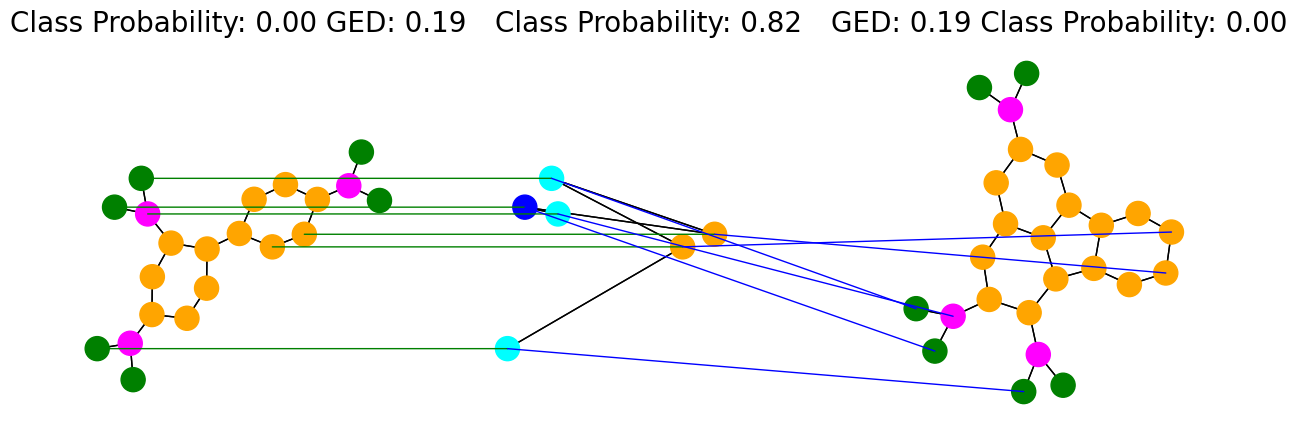

In [75]:
# Mutagen. 
gen_XGNN = run_XGNN(cls_idx=1, max_nodes=7)
obs_ex1 = test_data_list_1[1]
obs_ex2 = test_data_list_1[7]

vis_con_graph(gen_XGNN, obs_ex1, obs_ex2, GED_fn, explainee, 1)

Generated non-single node graph.


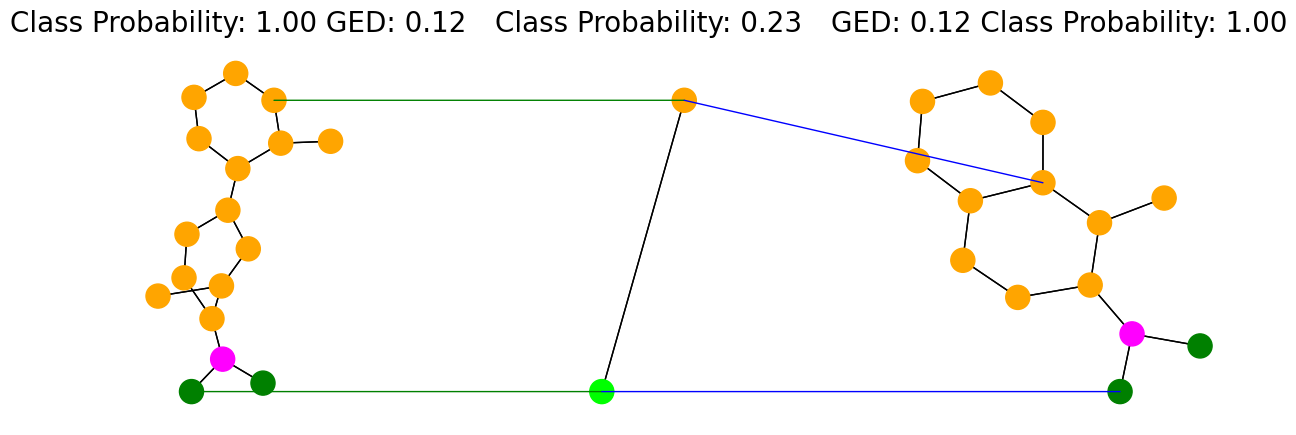

In [73]:
# Non-mutagen. 
gen_XGNN = run_XGNN(cls_idx=0, max_nodes=10)
obs_ex1 = test_data_list_0[1]
obs_ex2 = test_data_list_0[7]

vis_con_graph(gen_XGNN, obs_ex1, obs_ex2, GED_fn, explainee, 0)

## Parameter Probability Plot

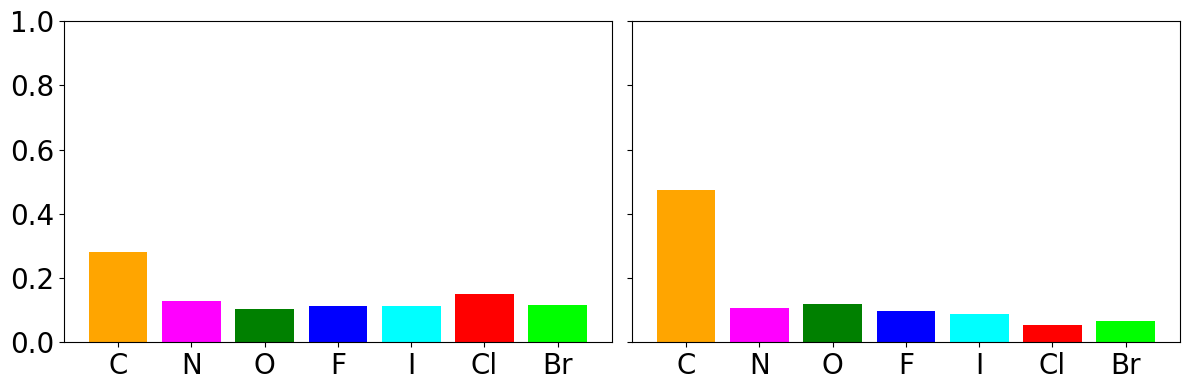

In [84]:
cell_type_probs_0 = compute_node_probs(0, 10, 1000)

cell_type_probs_1 = compute_node_probs(1, 10, 1000)

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[0].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

#axes[1].set_title('Nonmutagen', fontsize=20)
#axes[0].set_title('Mutagen', fontsize=20)
#axes[2].set_title('Untrained')

axes[1].tick_params(axis='both', which='major', labelsize=20)
axes[0].tick_params(axis='both', which='major', labelsize=20)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()